# Readout-fidelity-corrected data processing (filename tag: `original`)

This notebook is written for manuscript reviewers and readers who want a clear, end-to-end description of how the released probability datasets are processed into the `P(α)` and `FI(α)` curves used throughout the manuscript.

The input CSVs in `data/` used here are already **readout-fidelity corrected** (i.e., corrected for measurement assignment errors). In the derived filenames written to `data_analysis/`, we refer to this style as `original`.

## What this notebook does
1. **Load** readout-corrected probability time series from CSV.
2. **Convert** time samples `t` to rotation angle `α` (radians) using a global decaying-cosine fit.
3. **Estimate** `dP/dα` locally using sliding-window fits in `α`.
4. **Compute** the classical Fisher information (FI) from the fitted derivative.
5. **Export** `α`, `P`, and `FI` to `data_analysis/*_alpha_P_FI_*_original.csv`.
6. **Assemble** the singlet panels and averaged FI curve used in the SI.

```mermaid
flowchart LR
  in["Readout-corrected populations P(t)\n(CSV in `data/`)"] --> alpha["Global fit → α(t)"]
  alpha --> local["Sliding-window fits in α\n→ dP/dα"]
  local --> fi["Compute FI(α)\n+ average across windows"]
  fi --> csv["Write `data_analysis/*_alpha_P_FI_*_original.csv`"]
  fi --> fig["Export SI figure panels"]
```

## Inputs
- Singlet datasets: `singlet_U{ x,y,z }_t_list_1218.csv` and `singlet_U{ x,y,z }_P_1218.csv`.
- Unentangled single-qubit baselines: `Ux_Uy_Uz_pre_xz_meas_xz_t_list_1218.csv` and `Ux_Uy_Uz_pre_xz_meas_xz_P_Q{1,2}_U{ x,y,z }_1218.csv`.
- By default inputs are loaded from `data/`. To point at a different folder, edit `load_directory` in the setup cell.

## Outputs
- CSV files written to `data_analysis/`.
- PDF/PNG figure exports written to `si_figures/`.

## How to run
Run the notebook top-to-bottom. If you see a file-not-found error, confirm that the repository `data/` folder is present and that `load_directory` points to it.


## Setup

This cell imports dependencies and resolves repository-relative paths so the notebook can be run from different working directories. By default, `load_directory` points at the repo's `data/` folder.


In [460]:
import os
from pathlib import Path

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Resolve the input data directory from common repository locations.
candidates = [
    Path("data"),
    Path("Data"),
    Path("..") / "data",
    Path("..") / "Data",
    Path.cwd() / "data",
    Path.cwd() / "Data",
    Path.cwd().parent / "data",
    Path.cwd().parent / "Data",
]
load_directory = None
for cand in candidates:
    if cand.exists():
        load_directory = str(cand)
        break

if not load_directory:
    load_directory = "data"

print("Loading data from:", load_directory)



Working directory: /Users/chellymac/projects/positronium-sensing
Loading data from: data


## Global plot style

For consistency across SI panels, we define shared Matplotlib style settings (fonts, line widths, marker styles, and `0, π, 2π` tick labels). Most plots in this notebook reuse these settings.


In [461]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style: axes + ticks (SI panel styling) ---
lw = 1
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
mpl.rcParams['text.usetex'] = _HAS_TEX
mpl.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if mpl.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')

# Figure size (8.6 cm × 5 cm) -> inches
# Standard SI panel size used across exports.
fig_size = np.asarray([8.6, 5]) / 2.54

# Plot styles for the three rotation axes.
# We keep a consistent color/marker mapping across the SI:
#   x-axis rotation -> purple squares, y-axis rotation -> orange triangles, z-axis rotation -> gray circles.
style_x = dict(color="#6D00C9", marker="s", linestyle="-", markersize=5.0, label=r"$\hat{x}$")
style_y = dict(color="#F9AE2A", marker="^", linestyle="-", markersize=5.0, label=r"$\hat{y}$")
style_z = dict(color="#777777", marker="o", linestyle="-", markersize=5.0, label=r"$\hat{z}$")

# Common x-axis tick locations/labels (0, π, 2π).
# Many of the plots in this notebook show α on a grid that may extend beyond 2π,
# but these labels provide familiar reference points.
xticks = [0, np.pi, 2*np.pi]
xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]





## Shared single-qubit functions

These helper functions implement the classical Fisher information extraction for single-qubit probability curves.

- `t_to_alpha_with_params`: fits a decaying cosine model in time to infer the rotation rate, then converts `t → α`.
- `analyze_single_qubit_FI`: sliding-window FI for cosine-like signals.
- `analyze_single_qubit_FI_linear`: sliding-window FI for nearly-flat signals (linear local model).
- `save_alpha_P_FI`: exports `α`, `P`, and `FI` for downstream plotting notebooks.


In [462]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def _sigmoid_stable(x):
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x, dtype=float)
    pos = x >= 0.0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    exp_x = np.exp(x[~pos])
    out[~pos] = exp_x / (1.0 + exp_x)
    return out


def sigmoid_quadratic(alpha, q2, q1, q0):
    alpha = np.asarray(alpha, dtype=float)
    z = q2 * alpha * alpha + q1 * alpha + q0
    return _sigmoid_stable(z)


def sigmoid_quadratic_derivative(alpha, q2, q1, q0):
    alpha = np.asarray(alpha, dtype=float)
    p = sigmoid_quadratic(alpha, q2, q1, q0)
    dz_dalpha = 2.0 * q2 * alpha + q1
    return p * (1.0 - p) * dz_dalpha


def _initial_sigmoid_quadratic(alpha, p_obs, eps=1e-6):
    alpha = np.asarray(alpha, dtype=float)
    p_obs = np.asarray(p_obs, dtype=float)
    p_clip = np.clip(p_obs, eps, 1.0 - eps)
    logit = np.log(p_clip / (1.0 - p_clip))

    if len(alpha) >= 3 and np.ptp(alpha) > 0:
        try:
            q2, q1, q0 = np.polyfit(alpha, logit, 2)
            return np.array([q2, q1, q0], dtype=float)
        except (np.linalg.LinAlgError, ValueError):
            pass

    mean_p = float(np.mean(p_clip))
    q0 = np.log(mean_p / (1.0 - mean_p))
    return np.array([0.0, 0.0, q0], dtype=float)


def _fit_sigmoid_quadratic(alpha_subset, p_subset):
    p0 = _initial_sigmoid_quadratic(alpha_subset, p_subset)
    try:
        params, _ = curve_fit(
            sigmoid_quadratic,
            alpha_subset,
            p_subset,
            p0=p0,
            maxfev=20000,
        )
        return np.asarray(params, dtype=float)
    except RuntimeError:
        return p0


def _alpha_window_indices(alpha_sorted, alpha_window_size=0.8, step=1, min_points=3):
    alpha_sorted = np.asarray(alpha_sorted, dtype=float)
    if step < 1:
        raise ValueError("step must be at least 1.")
    if alpha_window_size is None:
        return []
    if alpha_window_size <= 0:
        raise ValueError("alpha_window_size must be > 0.")

    N = len(alpha_sorted)
    windows = []
    for start in range(0, N - min_points + 1, step):
        alpha_stop = alpha_sorted[start] + alpha_window_size
        end = int(np.searchsorted(alpha_sorted, alpha_stop, side="right"))
        if end - start >= min_points:
            windows.append((start, end))
    return windows


def analyze_single_qubit_FI(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
    label=None,
    eps=1e-9,
    alpha_grid_points=100,
    alpha_window_size=0.8,
):
    """
    Sliding-window Fisher information analysis in alpha-space using local
    sigmoid(quadratic) fits:

        P(alpha) = sigmoid(q2 * alpha^2 + q1 * alpha + q0)

    with analytic derivative

        dP/dalpha = P(1-P) * (2*q2*alpha + q1)

    The FI is computed as

        FI(alpha) = (dP/dalpha)^2 / [P(alpha) * (1-P(alpha))].

    Windows are built by alpha span (default 0.8 rad). The legacy index-space
    `window_size` is kept only as a fallback when alpha windows cannot be built.
    """

    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if alpha_data.shape != P_01.shape:
        raise ValueError("alpha_data and P_01 must have the same shape.")

    finite = np.isfinite(alpha_data) & np.isfinite(P_01)
    alpha_pos = alpha_data[finite]
    P_pos = P_01[finite]

    order = np.argsort(alpha_pos)
    alpha_pos = alpha_pos[order]
    P_pos = P_pos[order]

    N = len(alpha_pos)
    if N < 3:
        raise ValueError("Need at least 3 finite points for sigmoid(quadratic) FI analysis.")

    windows = _alpha_window_indices(
        alpha_pos,
        alpha_window_size=alpha_window_size,
        step=step,
        min_points=3,
    )

    if not windows:
        if window_size < 3:
            raise ValueError("window_size must be at least 3.")
        if window_size > N:
            raise ValueError(f"window_size ({window_size}) cannot exceed number of points ({N}).")
        windows = [(start, start + window_size) for start in range(0, N - window_size + 1, step)]

    global_fit_params = _fit_sigmoid_quadratic(alpha_pos, P_pos)
    P_global = sigmoid_quadratic(alpha_pos, *global_fit_params)

    alpha_segments = []
    P_segments = []
    FI_segments = []

    for start, end in windows:
        alpha_subset = alpha_pos[start:end]
        P_subset = P_pos[start:end]

        params_loc = _fit_sigmoid_quadratic(alpha_subset, P_subset)

        alpha_fine = np.linspace(alpha_subset.min(), alpha_subset.max(), n_alpha_points)
        P_alpha = sigmoid_quadratic(alpha_fine, *params_loc)
        dP_dalpha = sigmoid_quadratic_derivative(alpha_fine, *params_loc)

        denom = P_alpha * (1.0 - P_alpha)
        FI_alpha = np.full_like(P_alpha, np.nan, dtype=float)
        mask = denom > eps
        FI_alpha[mask] = (dP_dalpha[mask] ** 2) / denom[mask]

        alpha_segments.append(alpha_fine)
        P_segments.append(P_alpha)
        FI_segments.append(FI_alpha)

    if len(alpha_segments) == 0:
        raise RuntimeError("No windows were produced. Check alpha_window_size/window_size/step.")

    alpha_min = min(seg.min() for seg in alpha_segments)
    alpha_max = max(seg.max() for seg in alpha_segments)
    alpha_grid = np.linspace(alpha_min, alpha_max, alpha_grid_points)

    FI_grid_list = []
    for alpha_seg, FI_seg in zip(alpha_segments, FI_segments):
        FI_interp = np.full_like(alpha_grid, np.nan, dtype=float)
        mask = (alpha_grid >= alpha_seg.min()) & (alpha_grid <= alpha_seg.max())
        if np.any(mask):
            FI_interp[mask] = np.interp(alpha_grid[mask], alpha_seg, FI_seg)
        FI_grid_list.append(FI_interp)

    FI_stack = np.vstack(FI_grid_list)
    FI_avg = np.nanmean(FI_stack, axis=0)

    if make_plot:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        for idx, (alpha_seg, P_seg) in enumerate(zip(alpha_segments, P_segments)):
            fit_label = 'Piecewise sigmoid(quadratic) fits' if idx == 0 else None
            plt.plot(alpha_seg, P_seg, color='0.70', linewidth=1.0, alpha=0.35, label=fit_label, zorder=1)
        plt.plot(alpha_pos, P_pos, 'bo', markersize=3, label='Data', zorder=3)
        plt.xlabel(r'$\alpha$')
        plt.ylabel(r'$P(\alpha)$')
        title_left = "Single-qubit: P vs alpha (piecewise local fits)"
        if label:
            title_left += f" ({label})"
        plt.title(title_left)
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_grid, FI_avg, 'm-')
        plt.xlabel(r'$\alpha$')
        plt.ylabel('FI(alpha)')
        plt.title("Single-qubit: averaged FI vs alpha")
        if np.any(np.isfinite(FI_avg)):
            plt.ylim(-0.2, 1.1 * np.nanmax(FI_avg))
        plt.tight_layout()
        plt.show()

    return {
        "alpha_grid": alpha_grid,
        "FI_avg": FI_avg,
        "FI_stack": FI_stack,
        "alpha_segments": alpha_segments,
        "P_segments": P_segments,
        "FI_segments": FI_segments,
        "global_fit_params": tuple(global_fit_params),
        "alpha_window_size": alpha_window_size,
        "window_indices": windows,
    }


In [463]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def analyze_single_qubit_FI_linear(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label=None,
    eps=1e-9,
    alpha_window_size=0.8,
):
    """
    Backward-compatible wrapper for legacy linear-path calls.

    This now uses the same sigmoid(quadratic) local model as
    analyze_single_qubit_FI, including analytic derivatives and FI.
    """

    return analyze_single_qubit_FI(
        alpha_data=alpha_data,
        P_01=P_01,
        window_size=window_size,
        step=step,
        n_alpha_points=n_alpha_points,
        make_plot=make_plot,
        label=label,
        eps=eps,
        alpha_grid_points=n_alpha_points,
        alpha_window_size=alpha_window_size,
    )


In [464]:
def save_alpha_P_FI(basename, alpha, P, FI, save_dir, date_suffix):
    """
    Save a 3-column CSV: alpha, P, FI
    filename = f"{basename}_alpha_P_FI_{date_suffix}.csv"
    """
    alpha = np.asarray(alpha, float)
    P     = np.asarray(P,     float)
    FI    = np.asarray(FI,    float)

    data = np.column_stack([alpha, P, FI])

    filename = f"{basename}_alpha_P_FI_{date_suffix}.csv"
    save_path = os.path.join(save_dir, filename)
    os.makedirs(save_dir, exist_ok=True)

    np.savetxt(
        save_path,
        data,
        delimiter=",",
        header="alpha_rad,P,FI",
        comments=""
    )

    print(f"Saved {basename} α,P,FI to:", save_path)
    return save_path



In [465]:
def t_to_alpha_with_params(t_list, P_01, frequency_factor, initial_guess_global):
    """
    Global fit in time to get A, Omega, tau, y0, then convert t -> alpha.
    Returns:
        angle_list, tau, params = (A, Omega, tau, y0)
    """
    def fit_func_t(t, A, Omega, tau, y0):
        return A * np.cos(Omega * t) * np.exp(-t / tau) + y0

    params, _ = curve_fit(fit_func_t, t_list, P_01, p0=initial_guess_global)
    A, Omega, tau, y0 = params

    angle_list = t_list * Omega / frequency_factor
    return angle_list, tau, params


## Unentangled single-qubit data (Q1) — readout-fidelity-corrected

This section loads the Q1 probability time series for rotations about `\hat{x}`, `\hat{y}`, and `\hat{z}`.

The loaded arrays `P_Q1_Ux`, `P_Q1_Uy`, `P_Q1_Uz` have shape `(T, 2)` and represent corrected state populations:
- column 0: `P(|0\\rangle)`
- column 1: `P(|1\\rangle)`

We then compute `P(|1\\rangle)` as a function of `α` and extract the classical FI curve. The resulting `α`, `P`, `FI` are saved to `data_analysis/`.


In [466]:
import os
import pandas as pd

# Define the directory where files are saved
# (load_directory set in the setup cell above)

# Define the experiment name and date suffix
exp_name_xyz = 'Ux_Uy_Uz_pre_xz_meas_xz'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load the data from the CSV files
t_list = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q1_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q1_Ux_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q1_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q1_Uy_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q1_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q1_Uz_{date_suffix}.csv"), delimiter=",", skiprows=1)



original shapes: (153, 2) (153, 2) (153, 2)


/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


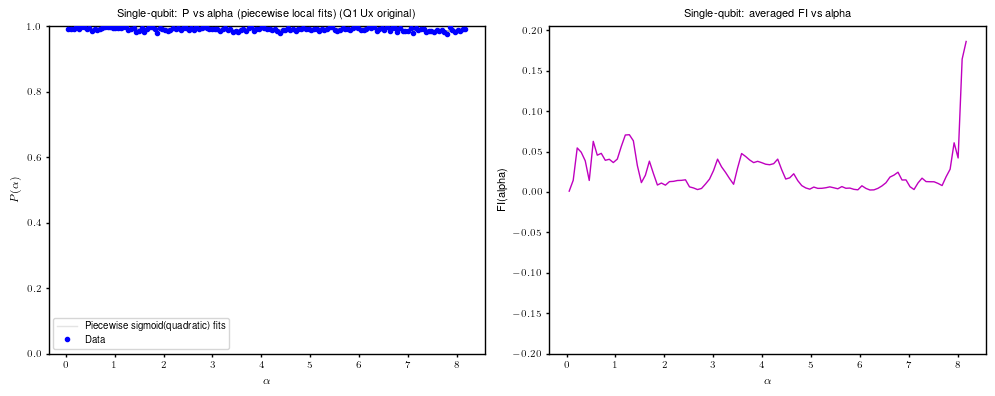

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


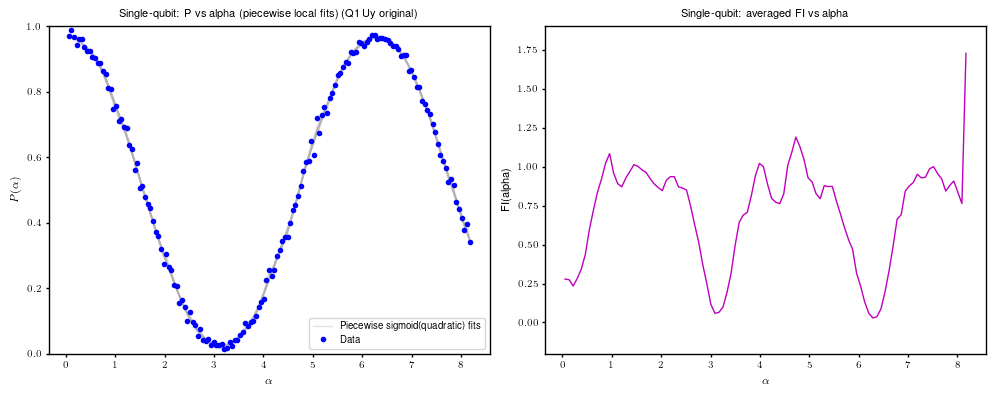

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


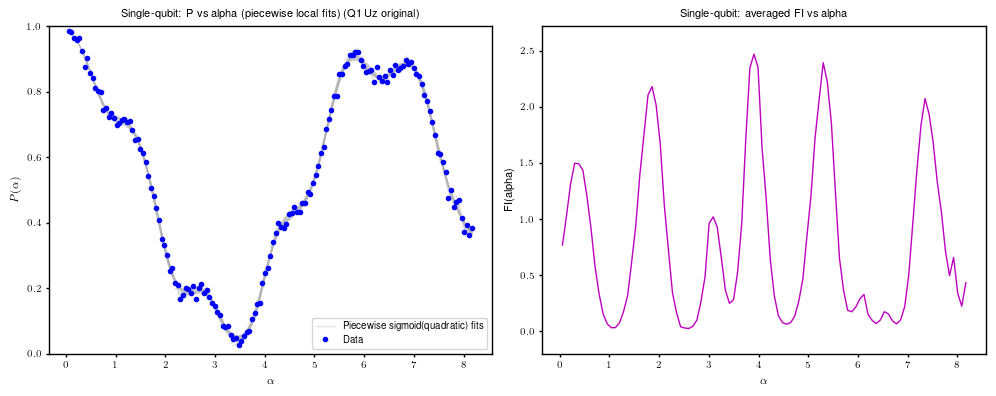

Saved Q1_Ux α,P,FI to: data_analysis/Q1_Ux_alpha_P_FI_1218_original.csv
Saved Q1_Uy α,P,FI to: data_analysis/Q1_Uy_alpha_P_FI_1218_original.csv
Saved Q1_Uz α,P,FI to: data_analysis/Q1_Uz_alpha_P_FI_1218_original.csv


'data_analysis/Q1_Uz_alpha_P_FI_1218_original.csv'

In [467]:
import numpy as np

# ===============================================================
# 1) Extract ORIGINAL P(|1>) from Q1 data
# ===============================================================
# P_Q1_Ux, P_Q1_Uy, P_Q1_Uz each have shape (T, 2): [P0_corr, P1_corr]
P_Q1_Ux_01 = P_Q1_Ux[:, 1]
P_Q1_Uy_01 = P_Q1_Uy[:, 1]
P_Q1_Uz_01 = P_Q1_Uz[:, 1]

print("original shapes:", P_Q1_Ux.shape, P_Q1_Uy.shape, P_Q1_Uz.shape)


# ===============================================================
# 2) Convert t → α using Uy ORIGINAL (defines a common α grid)
# ===============================================================
frequency_factor = 1
initial_guess_global = [0.5, 0.02, 10000, 0.5]

alpha_Q1_orig, tau_orig, params_orig = t_to_alpha_with_params(
    t_list,
    P_Q1_Uy_01,         # ORIGINAL Uy sets α(t)
    frequency_factor,
    initial_guess_global
)


# ===============================================================
# 3) Sliding-window FI (Q1 Ux, Uy, Uz ORIGINAL)
# ===============================================================

# ---- Q1 Ux ORIGINAL (flat / linear model) ----
res_Q1_Ux_original = analyze_single_qubit_FI_linear(
    alpha_data=alpha_Q1_orig,
    P_01=P_Q1_Ux_01,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q1 Ux original"
)
alpha_grid_Q1_Ux_original = res_Q1_Ux_original["alpha_grid"]
FI_Q1_Ux_original         = res_Q1_Ux_original["FI_avg"]

# ---- Q1 Uy ORIGINAL (cosine-like) ----
res_Q1_Uy_original = analyze_single_qubit_FI(
    alpha_data=alpha_Q1_orig,
    P_01=P_Q1_Uy_01,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q1 Uy original"
)
alpha_grid_Q1_Uy_original = res_Q1_Uy_original["alpha_grid"]
FI_Q1_Uy_original         = res_Q1_Uy_original["FI_avg"]

# ---- Q1 Uz ORIGINAL (cosine-like) ----
res_Q1_Uz_original = analyze_single_qubit_FI(
    alpha_data=alpha_Q1_orig,
    P_01=P_Q1_Uz_01,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q1 Uz original"
)
alpha_grid_Q1_Uz_original = res_Q1_Uz_original["alpha_grid"]
FI_Q1_Uz_original         = res_Q1_Uz_original["FI_avg"]


# ===============================================================
# 4) Interpolate ORIGINAL P(α) onto the FI α-grids
# ===============================================================
P_Q1_Ux_01_interp_original = np.interp(
    alpha_grid_Q1_Ux_original,
    alpha_Q1_orig,
    P_Q1_Ux_01
)

P_Q1_Uy_01_interp_original = np.interp(
    alpha_grid_Q1_Uy_original,
    alpha_Q1_orig,
    P_Q1_Uy_01
)

P_Q1_Uz_01_interp_original = np.interp(
    alpha_grid_Q1_Uz_original,
    alpha_Q1_orig,
    P_Q1_Uz_01
)


# ===============================================================
# 5) Save α, P, FI to CSV (Q1 original)
# ===============================================================
save_dir = "data_analysis"
date_suffix_original = "1218_original"

# Ux
save_alpha_P_FI(
    basename="Q1_Ux",
    alpha=alpha_grid_Q1_Ux_original,
    P=P_Q1_Ux_01_interp_original,
    FI=FI_Q1_Ux_original,
    save_dir=save_dir,
    date_suffix=date_suffix_original
)

# Uy
save_alpha_P_FI(
    basename="Q1_Uy",
    alpha=alpha_grid_Q1_Uy_original,
    P=P_Q1_Uy_01_interp_original,
    FI=FI_Q1_Uy_original,
    save_dir=save_dir,
    date_suffix=date_suffix_original
)

# Uz
save_alpha_P_FI(
    basename="Q1_Uz",
    alpha=alpha_grid_Q1_Uz_original,
    P=P_Q1_Uz_01_interp_original,
    FI=FI_Q1_Uz_original,
    save_dir=save_dir,
    date_suffix=date_suffix_original
)


## Unentangled single-qubit data (Q2) — readout-fidelity-corrected

Same workflow as Q1, but for the second qubit.

The loaded arrays `P_Q2_Ux`, `P_Q2_Uy`, `P_Q2_Uz` have shape `(T, 2)` with columns `[P(|0\\rangle), P(|1\\rangle)]` (readout-fidelity-corrected). We compute the FI curve for each rotation axis and save to `data_analysis/`.


In [468]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def analyze_single_qubit_FI_q2(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
    label=None,
    eps=1e-9,
    alpha_window_size=0.8,
):
    """
    Backward-compatible Q2 wrapper.

    Uses the same sigmoid(quadratic) sliding-window FI pipeline as
    analyze_single_qubit_FI.
    """

    return analyze_single_qubit_FI(
        alpha_data=alpha_data,
        P_01=P_01,
        window_size=window_size,
        step=step,
        n_alpha_points=n_alpha_points,
        make_plot=make_plot,
        label=label,
        eps=eps,
        alpha_grid_points=n_alpha_points,
        alpha_window_size=alpha_window_size,
    )


import os
import pandas as pd

# Define the directory where files are saved
# (load_directory set in the setup cell above)

# Define the experiment name and date suffix
exp_name_xyz = 'Ux_Uy_Uz_pre_xz_meas_xz'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load the data from the CSV files
t_list = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Ux_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Uy_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Q2_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_xyz}_P_Q2_Uz_{date_suffix}.csv"), delimiter=",", skiprows=1)


Q2 original shapes: (153, 2) (153, 2) (153, 2)


/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


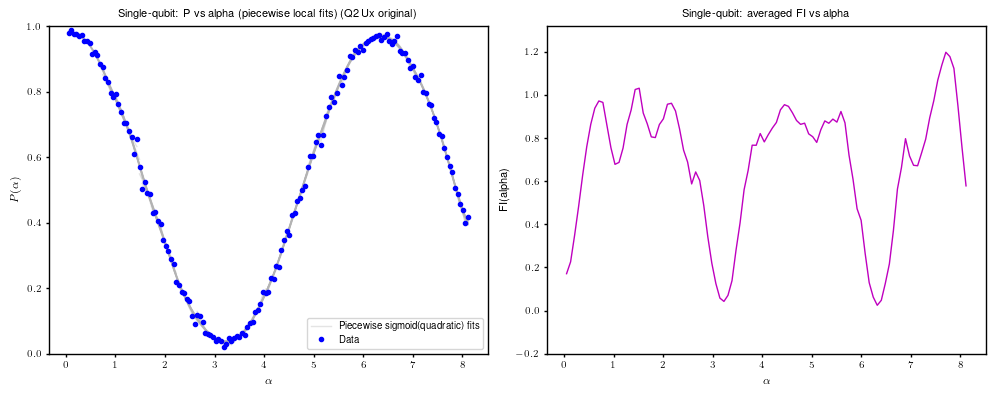

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


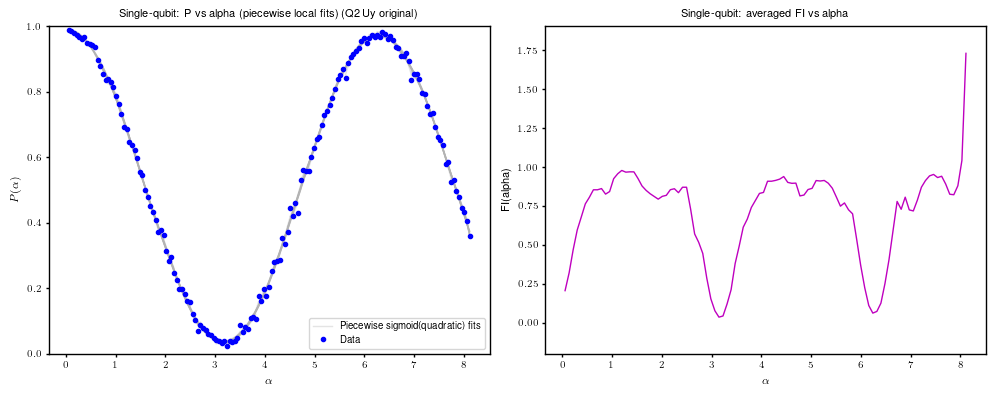

/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


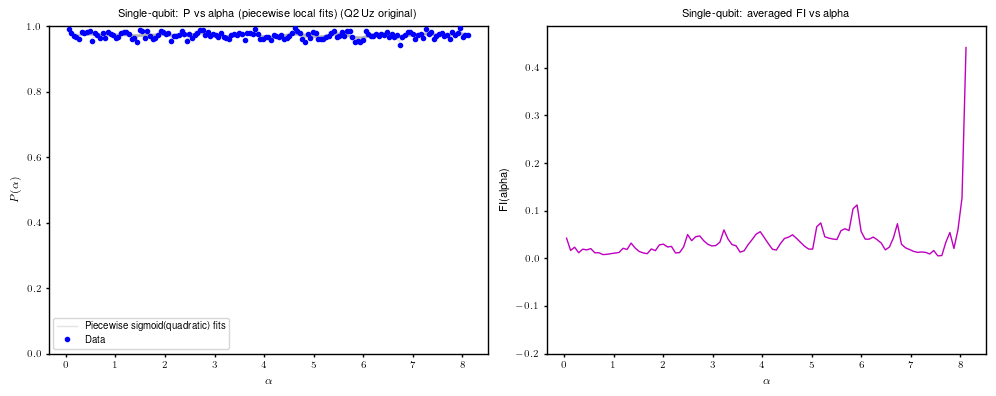

Saved Q2_Ux α,P,FI to: data_analysis/Q2_Ux_alpha_P_FI_1218_original.csv
Saved Q2_Uy α,P,FI to: data_analysis/Q2_Uy_alpha_P_FI_1218_original.csv
Saved Q2_Uz α,P,FI to: data_analysis/Q2_Uz_alpha_P_FI_1218_original.csv


'data_analysis/Q2_Uz_alpha_P_FI_1218_original.csv'

In [469]:
import numpy as np

# ===============================================================
# 1) Extract ORIGINAL P(|1>) from Q2 data
# ===============================================================
# P_Q2_Ux, P_Q2_Uy, P_Q2_Uz each have shape (T, 2): [P0, P1]
P_Q2_Ux_01 = P_Q2_Ux[:, 0]
P_Q2_Uy_01 = P_Q2_Uy[:, 0]
P_Q2_Uz_01 = P_Q2_Uz[:, 0]

print("Q2 original shapes:", P_Q2_Ux.shape, P_Q2_Uy.shape, P_Q2_Uz.shape)

# ===============================================================
# 2) Convert t → α using Uy ORIGINAL (defines a common α grid)
# ===============================================================
frequency_factor = 1
initial_guess_global = [0.5, 0.02, 10000, 0.5]

alpha_Q2_orig, tau_Q2_orig, params_Q2_orig = t_to_alpha_with_params(
    t_list,          # same t_list as for Q2
    P_Q2_Uy_01,      # ORIGINAL Uy sets α(t) for Q2
    frequency_factor,
    initial_guess_global
)

# ===============================================================
# 3) Sliding-window FI (Q2 Ux, Uy, Uz ORIGINAL)
# ===============================================================

# ---- Q2 Ux ORIGINAL (cosine-like) ----
res_Q2_Ux_original = analyze_single_qubit_FI_q2(
    alpha_data=alpha_Q2_orig,
    P_01=P_Q2_Ux_01,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q2 Ux original"
)
alpha_grid_Q2_Ux_original = res_Q2_Ux_original["alpha_grid"]
FI_Q2_Ux_original         = res_Q2_Ux_original["FI_avg"]

# ---- Q2 Uy ORIGINAL (cosine-like) ----
res_Q2_Uy_original = analyze_single_qubit_FI_q2(
    alpha_data=alpha_Q2_orig,
    P_01=P_Q2_Uy_01,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q2 Uy original"
)
alpha_grid_Q2_Uy_original = res_Q2_Uy_original["alpha_grid"]
FI_Q2_Uy_original         = res_Q2_Uy_original["FI_avg"]

# ---- Q2 Uz ORIGINAL (flat / linear model) ----
res_Q2_Uz_original = analyze_single_qubit_FI_linear(
    alpha_data=alpha_Q2_orig,
    P_01=P_Q2_Uz_01,
    alpha_window_size=0.8,
    step=1,
    n_alpha_points=100,
    make_plot=True,
    label="Q2 Uz original"
)
alpha_grid_Q2_Uz_original = res_Q2_Uz_original["alpha_grid"]
FI_Q2_Uz_original         = res_Q2_Uz_original["FI_avg"]

# ===============================================================
# 4) Interpolate ORIGINAL P(α) onto the FI α-grids
# ===============================================================
P_Q2_Ux_01_interp_original = np.interp(
    alpha_grid_Q2_Ux_original,
    alpha_Q2_orig,
    P_Q2_Ux_01
)

P_Q2_Uy_01_interp_original = np.interp(
    alpha_grid_Q2_Uy_original,
    alpha_Q2_orig,
    P_Q2_Uy_01
)

P_Q2_Uz_01_interp_original = np.interp(
    alpha_grid_Q2_Uz_original,
    alpha_Q2_orig,
    P_Q2_Uz_01
)

# ===============================================================
# 5) Save α, P, FI to CSV (Q2 original)
# ===============================================================
save_dir = "data_analysis"
date_suffix_original = "1218_original"

# Ux
save_alpha_P_FI(
    basename="Q2_Ux",
    alpha=alpha_grid_Q2_Ux_original,
    P=P_Q2_Ux_01_interp_original,
    FI=FI_Q2_Ux_original,
    save_dir=save_dir,
    date_suffix=date_suffix_original
)

# Uy
save_alpha_P_FI(
    basename="Q2_Uy",
    alpha=alpha_grid_Q2_Uy_original,
    P=P_Q2_Uy_01_interp_original,
    FI=FI_Q2_Uy_original,
    save_dir=save_dir,
    date_suffix=date_suffix_original
)

# Uz
save_alpha_P_FI(
    basename="Q2_Uz",
    alpha=alpha_grid_Q2_Uz_original,
    P=P_Q2_Uz_01_interp_original,
    FI=FI_Q2_Uz_original,
    save_dir=save_dir,
    date_suffix=date_suffix_original
)


## Shared singlet-state functions

These helper functions implement FI extraction for the two-qubit singlet-state analysis using a cosine fit in `α` within sliding windows.

In this notebook, we focus on the probability of a specific computational-basis outcome (see below) as a function of `α`.


In [470]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def analyze_singlet_FI_alpha(
    alpha_data,
    P_01,
    subset_indices=None,
    n_alpha_points=1000,
    make_plot=True,
    eps=1e-9,
):
    """
    Local singlet FI extraction in alpha-space with a sigmoid(quadratic) model.
    """

    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if subset_indices is None:
        start, end = 0, len(alpha_data)
    else:
        start, end = subset_indices

    alpha_subset = alpha_data[start:end]
    P_subset = P_01[start:end]

    finite = np.isfinite(alpha_subset) & np.isfinite(P_subset)
    alpha_subset = alpha_subset[finite]
    P_subset = P_subset[finite]

    if len(alpha_subset) < 3:
        raise ValueError("Subset too small for sigmoid(quadratic) fit.")

    order = np.argsort(alpha_subset)
    alpha_subset = alpha_subset[order]
    P_subset = P_subset[order]

    params_subset = _fit_sigmoid_quadratic(alpha_subset, P_subset)

    alpha_fine = np.linspace(alpha_subset.min(), alpha_subset.max(), n_alpha_points)
    P_alpha = sigmoid_quadratic(alpha_fine, *params_subset)
    dP_dalpha = sigmoid_quadratic_derivative(alpha_fine, *params_subset)

    denom = P_alpha * (1.0 - P_alpha)
    FI_alpha = np.full_like(P_alpha, np.nan)
    mask = denom > eps
    FI_alpha[mask] = (dP_dalpha[mask] ** 2) / denom[mask]

    if make_plot:
        xticks = [0, np.pi, 2*np.pi]
        xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.plot(alpha_data, P_01, color=style_x['color'], marker=style_x['marker'], linestyle=style_x['linestyle'], markersize=style_x['markersize'], label='Measured P(alpha)')
        plt.plot(alpha_subset, P_subset, color=style_y['color'], marker=style_y['marker'], linestyle=style_y['linestyle'], markersize=style_y['markersize'], label='Windowed subset')
        plt.plot(alpha_fine, P_alpha, color=style_z['color'], marker=style_z['marker'], linestyle=style_z['linestyle'], markersize=style_z['markersize'], label='Subset fit: sigmoid(quadratic)')
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('P(alpha)')
        plt.xticks(xticks, xticklabels)
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_fine, FI_alpha, color=style_z['color'], marker=style_z['marker'], linestyle=style_z['linestyle'], markersize=style_z['markersize'])
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('FI(alpha)')
        plt.xticks(xticks, xticklabels)
        if np.nanmax(FI_alpha) > 0:
            plt.ylim(-0.2, np.nanmax(FI_alpha) * 1.1)
        plt.tight_layout()
        plt.show()

    return {
        "subset_fit_params": tuple(params_subset),
        "alpha_data": alpha_data,
        "alpha_subset": alpha_subset,
        "alpha_fine": alpha_fine,
        "P_alpha": P_alpha,
        "dP_dalpha": dP_dalpha,
        "FI_alpha": FI_alpha,
    }


In [471]:
import numpy as np
import matplotlib.pyplot as plt


def analyze_singlet_FI(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
    alpha_window_size=0.8,
):
    """
    Sliding-window singlet FI analysis in alpha-space using sigmoid(quadratic)
    local fits and analytic derivatives.
    """

    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if len(alpha_data) != len(P_01):
        raise ValueError("alpha_data and P_01 must have the same length.")

    finite = np.isfinite(alpha_data) & np.isfinite(P_01)
    alpha_sorted = alpha_data[finite]
    P_sorted = P_01[finite]

    order = np.argsort(alpha_sorted)
    alpha_sorted = alpha_sorted[order]
    P_sorted = P_sorted[order]

    N = len(alpha_sorted)
    if N < 3:
        raise ValueError("Need at least 3 finite points for singlet FI analysis.")

    windows = _alpha_window_indices(
        alpha_sorted,
        alpha_window_size=alpha_window_size,
        step=step,
        min_points=3,
    )

    if not windows:
        if window_size < 3:
            raise ValueError("window_size must be at least 3 points.")
        if window_size > N:
            raise ValueError("window_size cannot exceed number of data points.")
        windows = [(start, start + window_size) for start in range(0, N - window_size + 1, step)]

    alpha_segments = []
    P_segments = []
    FI_segments = []

    for start, end in windows:
        res = analyze_singlet_FI_alpha(
            alpha_data=alpha_sorted,
            P_01=P_sorted,
            subset_indices=(start, end),
            n_alpha_points=n_alpha_points,
            make_plot=False,
        )

        alpha_segments.append(res["alpha_fine"])
        P_segments.append(res["P_alpha"])
        FI_segments.append(res["FI_alpha"])

    if len(alpha_segments) == 0:
        raise RuntimeError("No windows were generated; check alpha_window_size/window_size/step.")

    alpha_min = min(seg.min() for seg in alpha_segments)
    alpha_max = max(seg.max() for seg in alpha_segments)
    alpha_grid = np.linspace(alpha_min, alpha_max, 100)

    FI_grid_list = []
    for alpha_seg, FI_seg in zip(alpha_segments, FI_segments):
        FI_interp = np.full_like(alpha_grid, np.nan, dtype=float)
        mask = (alpha_grid >= alpha_seg.min()) & (alpha_grid <= alpha_seg.max())
        if np.any(mask):
            FI_interp[mask] = np.interp(alpha_grid[mask], alpha_seg, FI_seg)
        FI_grid_list.append(FI_interp)

    FI_stack = np.vstack(FI_grid_list)
    FI_avg = np.nanmean(FI_stack, axis=0)

    if make_plot:
        xticks = [0, np.pi, 2*np.pi]
        xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        for idx, (alpha_seg, P_seg) in enumerate(zip(alpha_segments, P_segments)):
            fit_label = 'Piecewise sigmoid(quadratic) fits' if idx == 0 else None
            plt.plot(alpha_seg, P_seg, color=style_z['color'], linewidth=1.0, alpha=0.25, label=fit_label, zorder=1)
        plt.plot(alpha_sorted, P_sorted, color=style_x['color'], marker=style_x['marker'], linestyle=style_x['linestyle'], markersize=style_x['markersize'], label='Measured P(alpha)', zorder=3)
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('P(alpha)')
        plt.xticks(xticks, xticklabels)
        plt.title("Singlet: P vs alpha")
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_grid, FI_avg, color=style_z['color'], marker=style_z['marker'], linestyle=style_z['linestyle'], markersize=style_z['markersize'])
        plt.xlabel(r'$\alpha$ (radians)')
        plt.ylabel('FI(alpha)')
        plt.xticks(xticks, xticklabels)
        if np.any(np.isfinite(FI_avg)):
            plt.ylim(-0.2, 1.1 * np.nanmax(FI_avg))
        plt.title("Singlet: averaged FI vs alpha (sliding windows)")

        plt.tight_layout()
        plt.show()

    return {
        "alpha_grid": alpha_grid,
        "FI_avg": FI_avg,
        "FI_stack": FI_stack,
        "alpha_segments": alpha_segments,
        "P_segments": P_segments,
        "FI_segments": FI_segments,
        "alpha_window_size": alpha_window_size,
        "window_indices": windows,
    }


## Singlet dataset (rotations about $\hat{x}$) — readout-fidelity-corrected

This section loads two-qubit population data for a singlet-state experiment under rotations about `\hat{x}`.

The loaded array `P_Ux` has shape `(T, 4)`. Throughout this project the columns correspond to computational-basis populations:
- column 0: `P(|00\\rangle)`
- column 1: `P(|01\\rangle)`
- column 2: `P(|10\\rangle)`
- column 3: `P(|11\\rangle)`

We analyze `P(|01\\rangle)` as the singlet readout channel and extract FI vs `α`.


In [472]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Experiment identifier and date tag used in the CSV filenames.
# The date tag (e.g. "1218") is part of the filename and does not affect the analysis logic.
exp_name_z = 'singlet_Ux'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load readout-fidelity-corrected probability time series from CSV.
t_list_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Ux = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_P_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_01_Ux = P_Ux[:,1]  # interpret column 1 as P(|01⟩)



In [473]:
# 1) Convert experimental time samples t -> rotation angle α (radians)
# We fit a decaying cosine in time to infer the oscillation frequency Ω, then define α = Ω t / frequency_factor.
# The frequency_factor is a convention used in the original analysis notebooks (kept here for consistency).
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]

alpha_data_Ux, tau_Ux, params_Ux = t_to_alpha_with_params(
    t_list_Ux,
    P_01_Ux,
    frequency_factor,
    initial_guess_global
)



/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


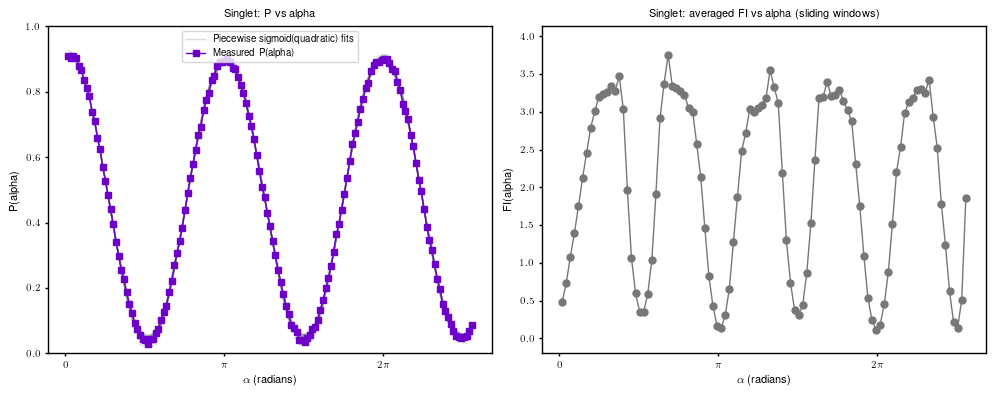

In [474]:
# ------------------ Run sliding-window FI analysis ------------------
res_Ux_original = analyze_singlet_FI(
    alpha_data = alpha_data_Ux,     # original alpha(t)
    P_01       = P_01_Ux,           # original P(α)
    alpha_window_size=0.8,
    step = 1,
    n_alpha_points = 300,
    make_plot = True
)

alpha_Ux_original = res_Ux_original["alpha_grid"]   # α grid after sliding window
FI_Ux_original    = res_Ux_original["FI_avg"]       # FI(α) averaged


In [475]:
# ------------------ Interpolate P(α) onto the new alpha grid ------------------
P_Ux_original_interp = np.interp(
    alpha_Ux_original,
    alpha_data_Ux,    # the original alpha(t)
    P_01_Ux           # the original P(α)
)


In [476]:
# ------------------ Save ------------------
date_suffix_original = "1218_original"

save_alpha_P_FI(
    basename   = "singlet_Ux",
    alpha      = alpha_Ux_original,
    P          = P_Ux_original_interp,
    FI         = FI_Ux_original,
    save_dir   = save_dir,
    date_suffix = date_suffix_original
)


Saved singlet_Ux α,P,FI to: data_analysis/singlet_Ux_alpha_P_FI_1218_original.csv


'data_analysis/singlet_Ux_alpha_P_FI_1218_original.csv'

## Singlet dataset (rotations about $\hat{y}$) — readout-fidelity-corrected

Same workflow as the $\hat{x}$ case, but for rotations about $\hat{y}$.


In [477]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Experiment identifier and date tag used in the CSV filenames.
# The date tag (e.g. "1218") is part of the filename and does not affect the analysis logic.
exp_name_z = 'singlet_Uy'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load readout-fidelity-corrected probability time series from CSV.
t_list_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Uy = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_P_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_01_Uy = P_Uy[:,1]  # interpret column 1 as P(|01⟩)



In [478]:
# 1) Convert experimental time samples t -> rotation angle α (radians)
# We fit a decaying cosine in time to infer the oscillation frequency Ω, then define α = Ω t / frequency_factor.
# The frequency_factor is a convention used in the original analysis notebooks (kept here for consistency).
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]

alpha_data_Uy, tau_Uy, params_Uy = t_to_alpha_with_params(
    t_list_Uy,
    P_01_Uy,
    frequency_factor,
    initial_guess_global
)



/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


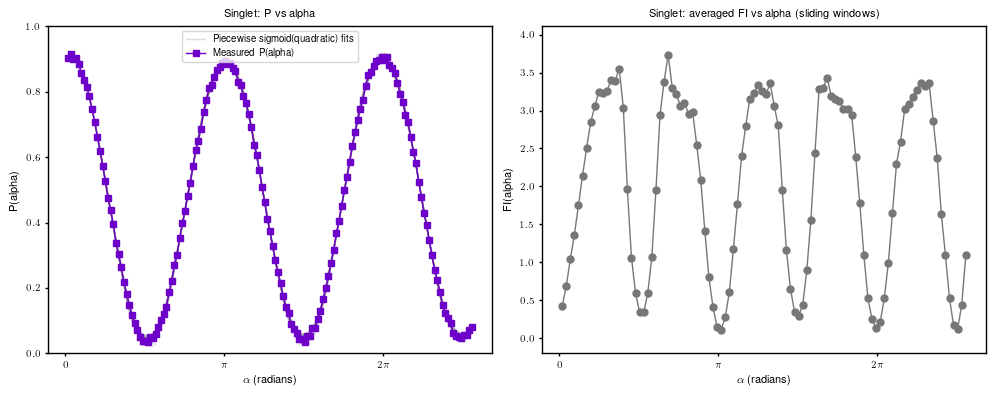

In [479]:
# ------------------ Run sliding-window FI analysis ------------------
res_Uy_original = analyze_singlet_FI(
    alpha_data = alpha_data_Uy,     # original alpha(t)
    P_01       = P_01_Uy,           # original P(α)
    alpha_window_size=0.8,
    step = 1,
    n_alpha_points = 300,
    make_plot = True
)

alpha_Uy_original = res_Uy_original["alpha_grid"]   # α grid after sliding window
FI_Uy_original    = res_Uy_original["FI_avg"]       # FI(α) averaged


In [480]:
# ------------------ Interpolate P(α) onto the new alpha grid ------------------
P_Uy_original_interp = np.interp(
    alpha_Uy_original,
    alpha_data_Uy,    # the original alpha(t)
    P_01_Uy           # the original P(α)
)


In [481]:
# ------------------ Save ------------------
date_suffix_original = "1218_original"

save_alpha_P_FI(
    basename   = "singlet_Uy",
    alpha      = alpha_Uy_original,
    P          = P_Uy_original_interp,
    FI         = FI_Uy_original,
    save_dir   = save_dir,
    date_suffix = date_suffix_original
)


Saved singlet_Uy α,P,FI to: data_analysis/singlet_Uy_alpha_P_FI_1218_original.csv


'data_analysis/singlet_Uy_alpha_P_FI_1218_original.csv'

## Singlet dataset (rotations about $\hat{z}$) — readout-fidelity-corrected

Same workflow as the $\hat{x}$ case, but for rotations about $\hat{z}$.


In [482]:
import os
import pandas as pd

# Directory containing the input CSV files.
# (load_directory set in the setup cell above)

# Experiment identifier and date tag used in the CSV filenames.
# The date tag (e.g. "1218") is part of the filename and does not affect the analysis logic.
exp_name_z = 'singlet_Uz'
date_suffix = '1218'  # Dataset tag used in the released filenames.

# Load readout-fidelity-corrected probability time series from CSV.
t_list_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_t_list_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_Uz = np.loadtxt(os.path.join(load_directory, f"{exp_name_z}_P_{date_suffix}.csv"), delimiter=",", skiprows=1)
P_01_Uz = P_Uz[:,1]  # interpret column 1 as P(|01⟩)



In [483]:
# 1) Convert experimental time samples t -> rotation angle α (radians)
# We fit a decaying cosine in time to infer the oscillation frequency Ω, then define α = Ω t / frequency_factor.
# The frequency_factor is a convention used in the original analysis notebooks (kept here for consistency).
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]

alpha_data_Uz, tau_Uz, params_Uz = t_to_alpha_with_params(
    t_list_Uz,
    P_01_Uz,
    frequency_factor,
    initial_guess_global
)



/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_86403/589690573.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


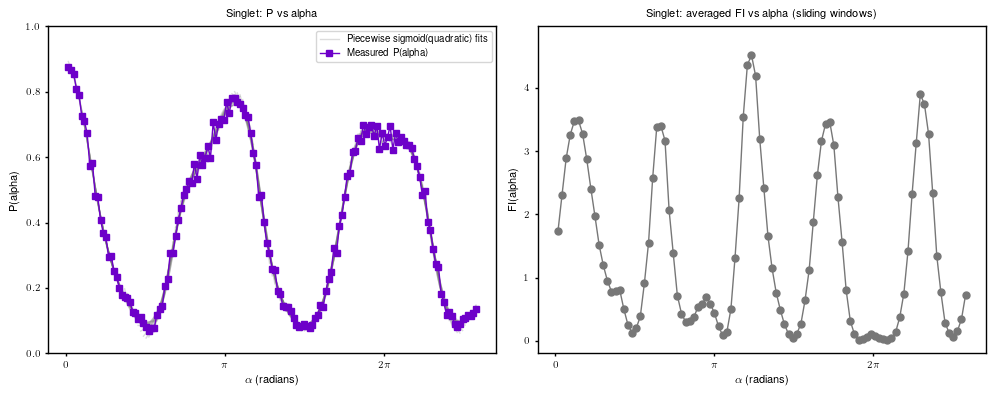

In [484]:
# ------------------ Run sliding-window FI analysis ------------------
res_Uz_original = analyze_singlet_FI(
    alpha_data = alpha_data_Uz,     # original alpha(t)
    P_01       = P_01_Uz,           # original P(α)
    alpha_window_size=0.8,
    step = 1,
    n_alpha_points = 300,
    make_plot = True
)

alpha_Uz_original = res_Uz_original["alpha_grid"]   # α grid after sliding window
FI_Uz_original    = res_Uz_original["FI_avg"]       # FI(α) averaged


In [485]:
# ------------------ Interpolate P(α) onto the new alpha grid ------------------
P_Uz_original_interp = np.interp(
    alpha_Uz_original,
    alpha_data_Uz,    # the original alpha(t)
    P_01_Uz           # the original P(α)
)


In [486]:
# ------------------ Save ------------------
date_suffix_original = "1218_original"

save_alpha_P_FI(
    basename   = "singlet_Uz",
    alpha      = alpha_Uz_original,
    P          = P_Uz_original_interp,
    FI         = FI_Uz_original,
    save_dir   = save_dir,
    date_suffix = date_suffix_original
)


Saved singlet_Uz α,P,FI to: data_analysis/singlet_Uz_alpha_P_FI_1218_original.csv


'data_analysis/singlet_Uz_alpha_P_FI_1218_original.csv'

## Readout-fidelity-corrected figures (singlet Ux/Uy/Uz)

These plots overlay the readout-fidelity-corrected singlet curves for the three rotation axes in a single frame.

- Top panel: probability `P(|\\Psi^-\\rangle)` (represented here by the chosen readout channel) vs `α`.
- Bottom panel: classical Fisher information vs `α`.

The curves are interpolated onto a common `α` grid and downsampled only for visual clarity (the saved CSVs retain full resolution).


In [487]:
import numpy as np

# -----------------------------
# Common alpha grid for singlet (readout-fidelity-corrected)
# -----------------------------

def _prep_alpha_y(alpha, y):
    alpha = np.asarray(alpha, float)
    y = np.asarray(y, float)
    m = np.isfinite(alpha) & np.isfinite(y)
    alpha, y = alpha[m], y[m]
    order = np.argsort(alpha)
    return alpha[order], y[order]

# Prepare (alpha, y) arrays and sort by alpha for interpolation.
# These inputs come from the three singlet experiments (Ux/Uy/Uz) after the FI extraction above.

# Prepare alpha/P arrays
Ux_a_P, Ux_P = _prep_alpha_y(alpha_Ux_original, P_Ux_original_interp)
Uy_a_P, Uy_P = _prep_alpha_y(alpha_Uy_original, P_Uy_original_interp)
Uz_a_P, Uz_P = _prep_alpha_y(alpha_Uz_original, P_Uz_original_interp)

# Prepare alpha/FI arrays
Ux_a_FI, Ux_FI = _prep_alpha_y(alpha_Ux_original, FI_Ux_original)
Uy_a_FI, Uy_FI = _prep_alpha_y(alpha_Uy_original, FI_Uy_original)
Uz_a_FI, Uz_FI = _prep_alpha_y(alpha_Uz_original, FI_Uz_original)

# Build a single shared alpha grid.
# We choose the overlap range across Ux/Uy/Uz so that interpolation stays within measured data
# (no extrapolation). This improves consistency when averaging across axes and comparing panels.

# Overlap region for a single shared alpha grid (no extrapolation)
alpha_min_overlap = max(np.nanmin(Ux_a_P), np.nanmin(Uy_a_P), np.nanmin(Uz_a_P))
alpha_max_overlap = min(np.nanmax(Ux_a_P), np.nanmax(Uy_a_P), np.nanmax(Uz_a_P))
if not (alpha_max_overlap > alpha_min_overlap):
    raise ValueError("No overlap among alpha grids for Ux/Uy/Uz.")

# Use the full overlap range so we only include physical data points
N_common = min(len(Ux_a_P), len(Uy_a_P), len(Uz_a_P))
alpha_common = np.linspace(alpha_min_overlap, alpha_max_overlap, N_common)

# Shared x-limits for plots (can extend beyond 2π if data do)
alpha_xlim_min = alpha_min_overlap
alpha_xlim_max = alpha_max_overlap

# Interpolate onto the common grid
P_Ux_common = np.interp(alpha_common, Ux_a_P, Ux_P)
P_Uy_common = np.interp(alpha_common, Uy_a_P, Uy_P)
P_Uz_common = np.interp(alpha_common, Uz_a_P, Uz_P)

FI_Ux_common = np.interp(alpha_common, Ux_a_FI, Ux_FI)
FI_Uy_common = np.interp(alpha_common, Uy_a_FI, Uy_FI)
FI_Uz_common = np.interp(alpha_common, Uz_a_FI, Uz_FI)

# Mean FI curve on the common grid
FI_mean_common = (FI_Ux_common + FI_Uy_common + FI_Uz_common) / 3.0

# Downsample for plotting only (keeps file sizes small and markers readable).
# The saved CSV files from earlier sections keep full resolution; this downsampling is just for display.

# Downsample indices (consistent across all curves)
DOWNSAMPLE_FRAC = 0.7
n = len(alpha_common)
_m = max(2, int(round(DOWNSAMPLE_FRAC * n)))
idx_ds = np.linspace(0, n - 1, _m).astype(int)

alpha_common_ds = alpha_common[idx_ds]

P_Ux_ds = P_Ux_common[idx_ds]
P_Uy_ds = P_Uy_common[idx_ds]
P_Uz_ds = P_Uz_common[idx_ds]

FI_Ux_ds = FI_Ux_common[idx_ds]
FI_Uy_ds = FI_Uy_common[idx_ds]
FI_Uz_ds = FI_Uz_common[idx_ds]

FI_mean_ds = FI_mean_common[idx_ds]



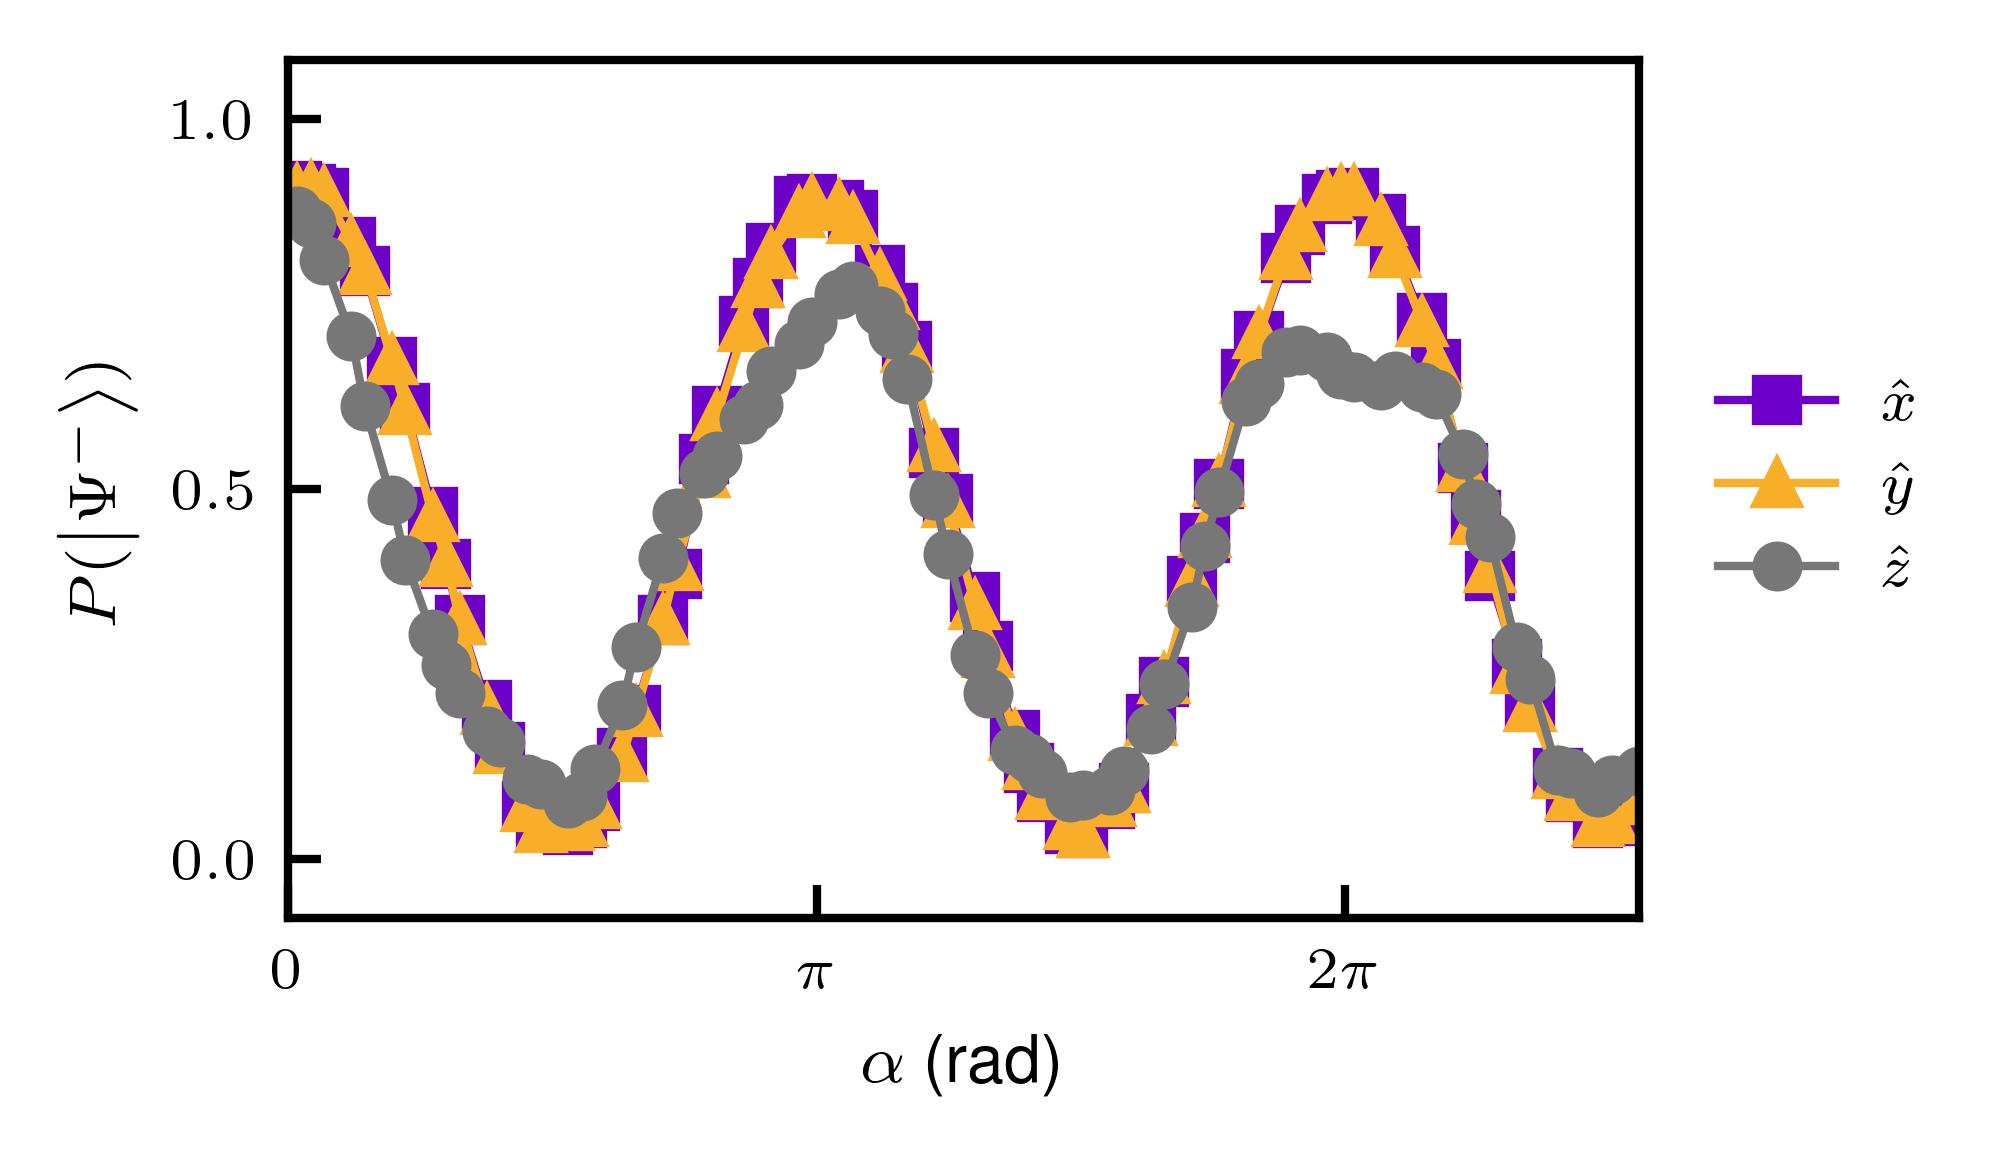

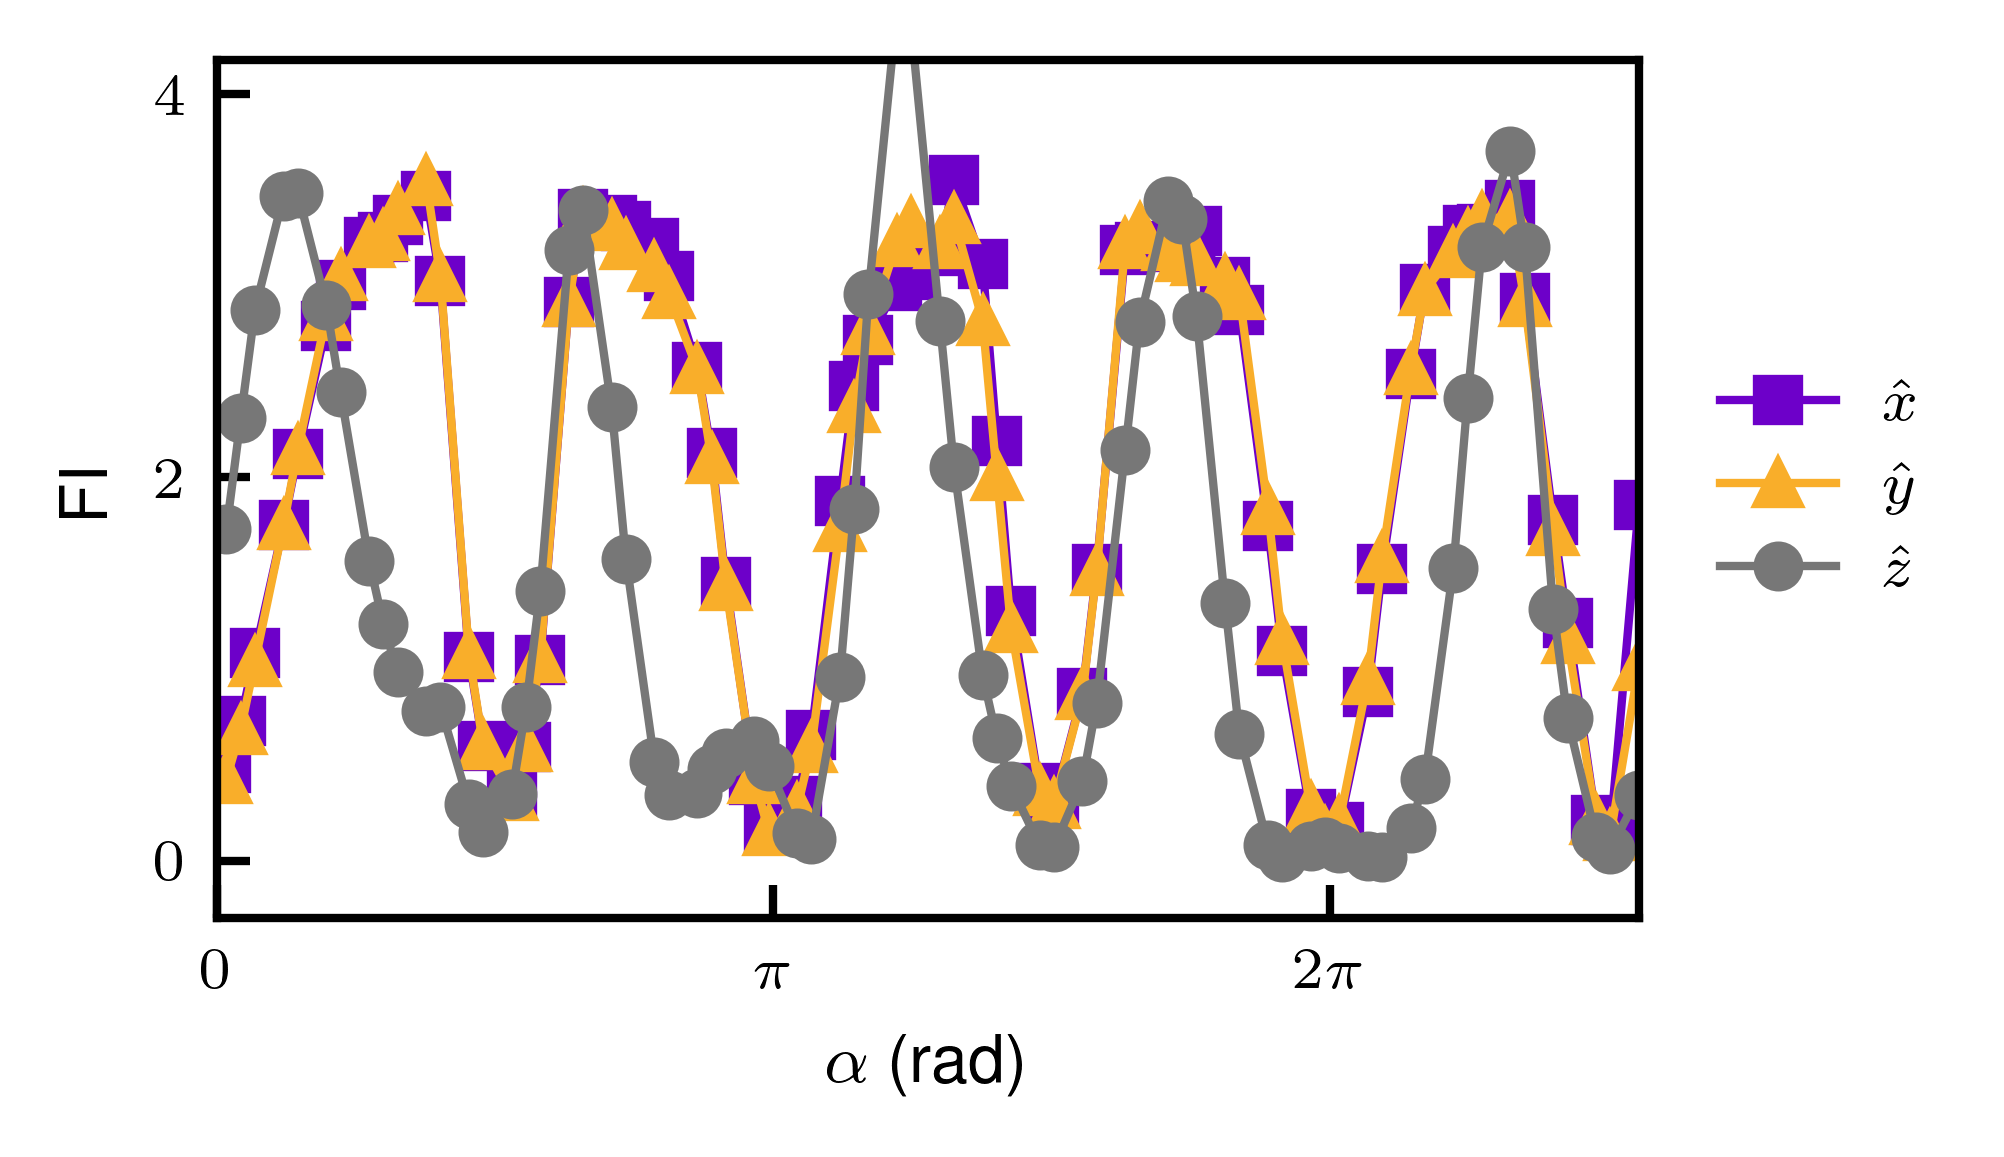

In [488]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style: axes + ticks (SI panel styling) ---
lw = 1
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
mpl.rcParams['text.usetex'] = _HAS_TEX
mpl.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if mpl.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')

# Figure size (8.6 cm × 5 cm) -> inches
fig_size = np.asarray([8.6, 5]) / 2.54

# plot styles (same as fig v2)
style_x = dict(color="#6D00C9", marker="s", linestyle="-", markersize=5.0, label=r"$\hat{x}$")
style_y = dict(color="#F9AE2A", marker="^", linestyle="-", markersize=5.0, label=r"$\hat{y}$")
style_z = dict(color="#777777", marker="o", linestyle="-", markersize=5.0, label=r"$\hat{z}$")

# Common x ticks in units of pi
xticks = [0, np.pi, 2*np.pi]
xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]

# -----------------------------
# Readout-fidelity-corrected data only ("original")
# Combined: all three curves in the same frame
# -----------------------------

# P(|Psi->) combined
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, P_Ux_ds, **style_x)
ax.plot(alpha_common_ds, P_Uy_ds, **style_y)
ax.plot(alpha_common_ds, P_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.08, 1.08)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel(r"$\alpha$ (rad)")
ax.set_ylabel(fr"$P({ket_psi})$")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ticks inside the frame
ax.tick_params(axis="both", which="both", direction="in")
ax.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction="in")
ax.tick_params(axis="y", which="major", left=True, right=False, labelleft=True,
               length=4, width=lw, direction="in")

fig.tight_layout()
plt.show()

# FI combined
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, FI_Ux_ds, **style_x)
ax.plot(alpha_common_ds, FI_Uy_ds, **style_y)
ax.plot(alpha_common_ds, FI_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r"$\alpha$ (rad)")
ax.set_ylabel("FI")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ticks inside the frame
ax.tick_params(axis="both", which="both", direction="in")
ax.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction="in")
ax.tick_params(axis="y", which="major", left=True, right=False, labelleft=True,
               length=4, width=lw, direction="in")

fig.tight_layout()
plt.show()








## Readout-fidelity-corrected average FI (singlet)

This panel shows the average FI curve across the three axes:

$$
\langle \mathcal{I}(\alpha) \rangle = \frac{\mathcal{I}_x(\alpha) + \mathcal{I}_y(\alpha) + \mathcal{I}_z(\alpha)}{3}.
$$

We compute the average on the shared $\alpha$ grid defined in the preceding cell, then plot the averaged curve and its mean value over $\alpha$.


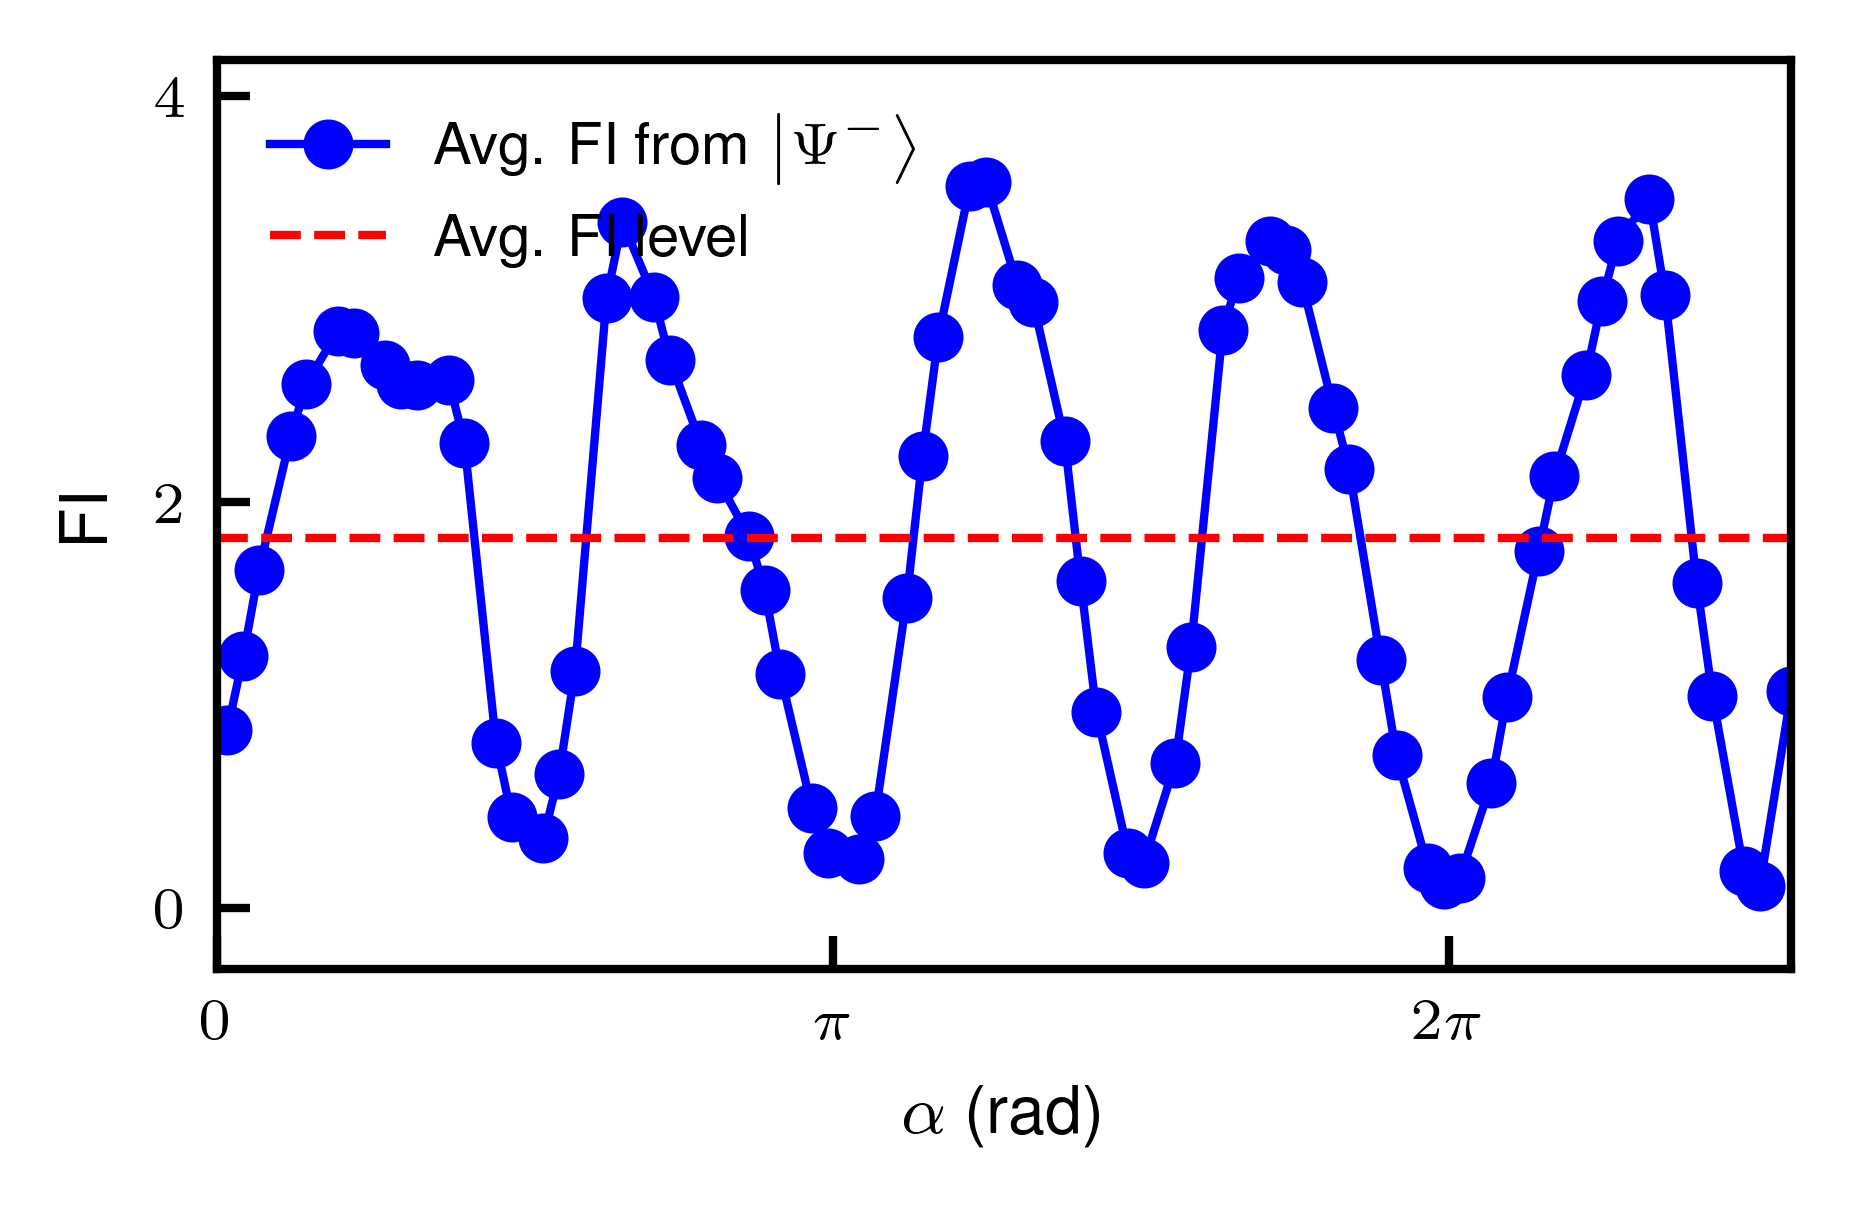

1.8254177836283871


In [489]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style: axes + ticks (SI panel styling) ---
lw = 1
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
mpl.rcParams['text.usetex'] = _HAS_TEX
mpl.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if mpl.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')

# Figure size (8.6 cm × 5 cm) -> inches
fig_size = np.asarray([8.6, 5]) / 2.54

# plot styles
style_mean = dict(color="blue", marker="o", linestyle="-", markersize=5.0, label=fr"Avg. FI from ${ket_psi}$")
style_hline = dict(color="red", linestyle="--", linewidth=1.0, label=r"Avg. FI level")

# Common x ticks in units of pi
xticks = [0, np.pi, 2*np.pi]
xticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]

# ---- plot ----
# Use common alpha grid and mean FI from the shared interpolation
singlet_Uxyz_mean_FI_ds_original = FI_mean_ds
singlet_FI_ds_original_mean = np.mean(singlet_Uxyz_mean_FI_ds_original)

fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, singlet_Uxyz_mean_FI_ds_original, **style_mean)
ax.axhline(singlet_FI_ds_original_mean, **style_hline)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r"$\alpha$ (rad)")
ax.set_ylabel("FI")
ax.legend(frameon=False, loc="best")

# ticks inside the frame
ax.tick_params(axis="both", which="both", direction="in")
ax.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction="in")
ax.tick_params(axis="y", which="major", left=True, right=False, labelleft=True,
               length=4, width=lw, direction="in")

outpath = os.path.join("si_figures", "SI_fig_v3_a.pdf")
os.makedirs(os.path.dirname(outpath), exist_ok=True)
fig.savefig(outpath, bbox_inches="tight")
plt.show()

print(singlet_FI_ds_original_mean)






